# Split Data

B Steele, Colorado State University, ROSSyndicate — last updated Sep 15, 2026

This notebook builds the production modeling dataset: it merges the filtered AquaMatch matchups (from `02_make_matches.Rmd`) with site-characteristic and antecedent-weather feature tables, resolves each site's HUC8 and a binary `shore_flag`, and assigns a fixed universal holdout plus five independent HUC8-random 4-fold cross-validation arrangements for a 5-seed model ensemble.

This replaces the original `03_split_data.Rmd`'s single HUC4-balanced 5-way split. That design was found to concentrate hard basins (the Lake Powell HUC4 and a forested HUC 1701 lake cluster) into single partitions structurally, rather than as an artifact of any one unlucky split — regrouping at HUC8 and averaging over several independent random seeds recovered 10–18% of that unevenly-distributed error. A single fixed holdout keeps every ensemble member's final evaluation directly comparable; the five independent 4-fold CV arrangements (used for feature selection, hyperparameter tuning, and training in `04_make_models.ipynb`) average out any one split's idiosyncratic basin placement rather than trusting it.

## Setup

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("python").resolve()))
import spatial_cv

AQUAMATCH_DIR = Path("aquamatch_files")

# ROSSyndicate light palette, matching the other scripts in this project
ROSS_LT_PAL = ["#002EA3", "#E70870", "#256BF5", "#745CFB", "#1E4D2B", "#56104E"]

## Read the filtered matchups and standardize band names

`02_make_matches.Rmd` writes the cross-sensor-harmonized (Gardner et al., LS7-referenced) bands as `*_corr_7`; the shared feature-engineering module (`python/features.py`) expects the `*_corr7` (no underscore) naming used throughout the v3 research pipeline, so we rename here rather than touching either the upstream script or the shared module.

In [2]:
df = pd.read_parquet(AQUAMATCH_DIR / "filtered_regional_sdd.parquet")

df = df.rename(columns={
    "red_corr_7": "red_corr7", "green_corr_7": "green_corr7", "blue_corr_7": "blue_corr7",
    "nir_corr_7": "nir_corr7", "swir1_corr_7": "swir1_corr7", "swir2_corr_7": "swir2_corr7",
    "surfacetemp_corr_7": "temp_corr7",
})

# LEDAPS (Landsat 4/5/7) vs. LaSRC (Landsat 8/9) atmospheric correction produces
# systematically different reflectance - a cheap, physically-real candidate feature
df["atm_corr_LaSRC"] = df["mission"].isin(["LC08", "LC09"]).astype(int)

print(f"{len(df):,} rows, {df.siteSR_id.nunique():,} sites")

11,210 rows, 1,462 sites


## Join site characteristics and antecedent weather

Two feature tables, built once (elevation + LakeCat catchment characteristics; gridded daily weather summarized over 1/3/7/30-day antecedent windows) and reused unchanged here:

- `site_characteristics.feather` joins on `siteSR_id` alone.
- `weather_summaries.feather` joins on `siteSR_id` + an **anchor date**. Antecedent-weather windows are anchored on whichever of (image date, field sample date) is *later*, not always the image date: `time_diff` is close to a 50/50 split between image-before-field and image-after-field, and when the image comes first, "previous N days before the image" never reaches forward to the field date — silently missing the image-to-field gap for about half the dataset. `anchor_date = max(image_date, field_date)` always covers that gap regardless of which direction the offset runs.

In [3]:
df["date"] = pd.to_datetime(df["date"])
df["field_date"] = pd.to_datetime(df["harmonized_local_time"]).dt.tz_localize(None).dt.normalize()
df["anchor_date"] = df[["date", "field_date"]].max(axis=1)
print(f"anchor_date != image date for {(df['anchor_date'] != df['date']).sum():,} / {len(df):,} rows "
      "(image-before-field cases)")

site_chars = (pd.read_feather(AQUAMATCH_DIR.parent / "outlier_rework" / "site_characteristics.feather")
              .drop(columns=["lat", "lon", "wb_nhd_id", "wb_gnis_name", "wb_areasqkm"]))
weather = (pd.read_feather(AQUAMATCH_DIR.parent / "outlier_rework" / "weather_summaries.feather")
           .rename(columns={"date": "anchor_date"}))
weather["anchor_date"] = pd.to_datetime(weather["anchor_date"])

df = df.merge(site_chars, on="siteSR_id", how="left").merge(weather, on=["siteSR_id", "anchor_date"], how="left")

n_missing_site = df["elevation_m"].isna().sum()
n_missing_weather = df["precip_mm_prev1"].isna().sum()
print(f"rows missing site characteristics: {n_missing_site} / {len(df)}")
print(f"rows missing weather: {n_missing_weather} / {len(df)} "
      "(xgboost/lightgbm handle missing values natively - left as NaN rather than dropped)")

anchor_date != image date for 4,760 / 11,210 rows (image-before-field cases)


rows missing site characteristics: 0 / 11210
rows missing weather: 15 / 11210 (xgboost/lightgbm handle missing values natively - left as NaN rather than dropped)


## Resolve HUC8 and derive `shore_flag`

`shore_flag` is a binary collapse of the site-quality-assurance shoreline flags: `1` if `flag_wb == 1` (the site's nearest-matched-waterbody join failed, i.e. the site sits outside its matched waterbody polygon) **or** `flag_optical_shoreline == 1` (the site is within 230 m of the matched waterbody's shoreline — a 200 m site buffer plus a 30 m optical pixel); `0` only when neither condition holds (open water, comfortably inside the waterbody). Unanimously retained by backward elimination across every seed and model in the v3 research pipeline (project memory `workflow-v3-findings`).

In [4]:
huc_lookup_path = AQUAMATCH_DIR / "downloads" / "siteSR_collated_WQP_NWIS_sites_with_NHD_info_2025-06-04.csv"
huc_lookup = (pd.read_csv(huc_lookup_path,
                          usecols=["siteSR_id", "assigned_HUC", "flag_wb", "flag_optical_shoreline"],
                          dtype={"siteSR_id": str, "assigned_HUC": str})
              .rename(columns={"assigned_HUC": "HUC8"})
              .drop_duplicates(subset="siteSR_id"))

df = df.merge(huc_lookup, on="siteSR_id", how="left")
assert df["HUC8"].notna().all(), "unresolved HUC8 for some sites"
assert (df["HUC8"].str[:4] == df["HUC4"]).all(), "HUC8 prefix disagrees with HUC4"

assert df["flag_wb"].isin([0, 1]).all(), "flag_wb has unexpected values"
assert df["flag_optical_shoreline"].dropna().isin([0, 1]).all(), "flag_optical_shoreline has unexpected values"
df["shore_flag"] = ((df["flag_wb"] == 1) | (df["flag_optical_shoreline"] == 1)).astype(int)
df = df.drop(columns=["flag_wb", "flag_optical_shoreline"])

print(df["shore_flag"].value_counts(normalize=True).rename("share"))

shore_flag
0    0.501338
1    0.498662
Name: share, dtype: float64


## Build the fixed holdout and five ensemble-seed CV arrangements

`spatial_cv.build_splits` (1) greedily bin-packs HUC8 groups, shuffled under a fixed seed, into 5 size-balanced partitions and takes partition 5 as a **permanent holdout** that no model ever trains on, then (2) re-shuffles the *remaining* ~80% of HUC8 groups into 4-fold CV arrangements independently for each of 5 ensemble seeds — the holdout itself never moves. The holdout seed (3) is carried over unchanged from the earlier partition-sensitivity sweep, which found it leaves both structurally-hard basins reasonably represented in the training pool (neither starved nor dominant) rather than an extreme split.

In [5]:
df = spatial_cv.build_splits(df)

print(f"fixed holdout: {df['is_holdout'].sum():,} rows ({df['is_holdout'].mean():.1%}), "
      f"CV pool: {(~df['is_holdout']).sum():,} rows")

# sanity check against the already-published partition_sensitivity numbers for
# this same holdout seed's concentration of the two structurally-hard basins.
# HUC4-level, since that's how partition_sensitivity originally reported it -
# a HUC4 can straddle multiple partitions since it's made up of several HUC8
# groups, each independently bin-packed
for huc4, expected_share in [("1701", 43.9), ("1407", 47.0)]:
    sub = df[df["HUC4"] == huc4]
    share = sub.groupby("holdout_part").size().max() / len(sub) * 100
    print(f"HUC4 {huc4} max-partition share: {share:.1f}% (partition_sensitivity reported {expected_share}%)")

for seed in spatial_cv.ENSEMBLE_SEEDS:
    counts = df.loc[~df["is_holdout"], f"cvfold_seed{seed}"].value_counts().sort_index()
    print(f"seed {seed} CV-fold sizes: {counts.tolist()}")

# HUC8-level detail: the split's actual atomic unit is HUC8, not HUC4 (each HUC8
# lands wholly in one partition by construction, so a "max-partition share" check
# at the HUC8 level is trivially 100% - instead, show where each of the largest
# HUC8 units inside the two structurally-hard HUC4s actually landed)
print("\nlargest HUC8 units within the structurally-hard HUC4s, and which split they landed in:")
hard_huc8 = (df[df["HUC4"].isin(["1701", "1407"])]
             .groupby(["HUC4", "HUC8", "is_holdout"]).size().rename("n")
             .reset_index().sort_values("n", ascending=False).head(10))
print(hard_huc8.to_string(index=False))

fixed holdout: 2,218 rows (19.8%), CV pool: 8,992 rows
HUC4 1701 max-partition share: 50.3% (partition_sensitivity reported 43.9%)
HUC4 1407 max-partition share: 48.2% (partition_sensitivity reported 47.0%)
seed 501 CV-fold sizes: [2154, 2473, 2184, 2181]
seed 502 CV-fold sizes: [2365, 2139, 2152, 2336]
seed 503 CV-fold sizes: [2621, 2108, 2074, 2189]
seed 504 CV-fold sizes: [2249, 2247, 2242, 2254]
seed 505 CV-fold sizes: [2200, 2228, 2341, 2223]

largest HUC8 units within the structurally-hard HUC4s, and which split they landed in:
HUC4     HUC8  is_holdout   n
1701 17010203        True 542
1407 14070006       False 285
1701 17010303       False 165
1701 17010208       False 164
1407 14070001       False 140
1407 14070003       False 136
1701 17010210       False 129
1701 17010101        True  71
1701 17010214       False  30
1407 14070005        True  30


## Visualize the splits

Map the fixed holdout against the CV pool, and one representative ensemble seed's 4-fold arrangement, as a spatial sanity check. HUC8 boundaries are drawn alongside HUC4 boundaries, since HUC8 is the split's actual unit — filtered from the national WBD geodatabase (`aquamatch_files/wbd_national`) down to just the HUC8s actually present in this dataset, and cached locally (`aquamatch_files/huc8_filtered.gdb`) the same way `01_filter_AquaMatch_Data.Rmd` already caches `huc4_filtered.gdb`, so later runs don't need to re-touch the (~2.7 GB) national file.

HUC8 boundaries: 195 of 195 distinct HUC8s in the dataset


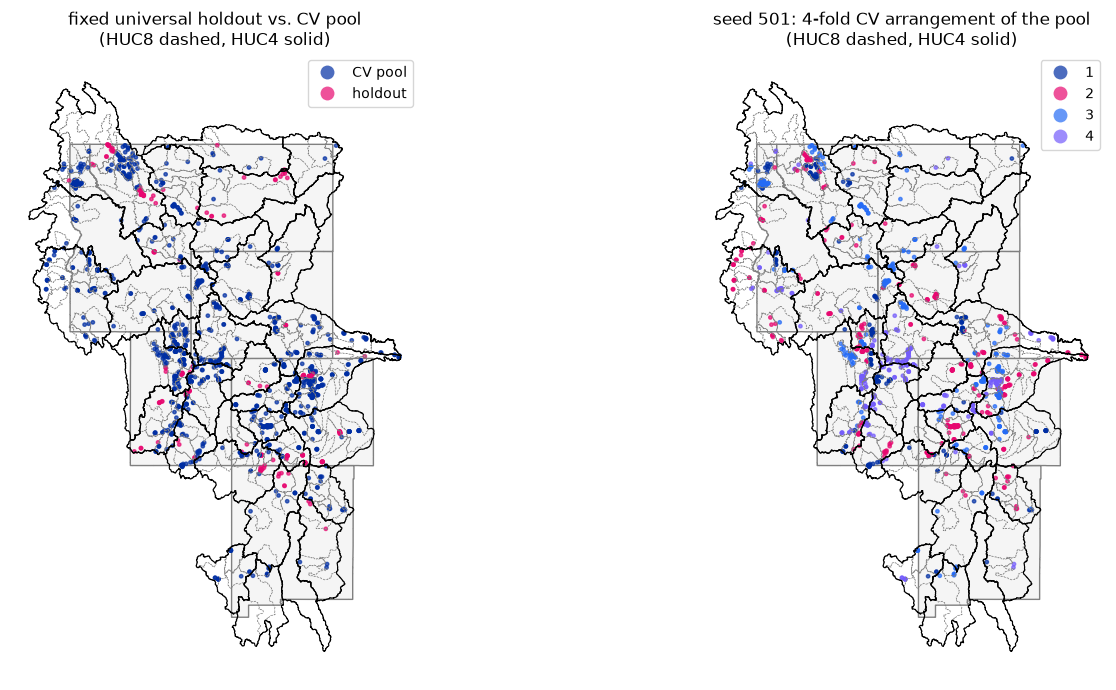

In [6]:
states = gpd.read_file(AQUAMATCH_DIR / "states.gdb", layer="states")
huc4s = gpd.read_file(AQUAMATCH_DIR / "huc4_filtered.gdb", layer="huc4_filtered")

huc8_cache_path = AQUAMATCH_DIR / "huc8_filtered.gdb"
if huc8_cache_path.exists():
    huc8s = gpd.read_file(huc8_cache_path, layer="huc8_filtered")
else:
    huc8_codes = sorted(df["HUC8"].unique())
    where = "huc8 IN (" + ",".join(f"'{c}'" for c in huc8_codes) + ")"
    huc8s = gpd.read_file(AQUAMATCH_DIR / "wbd_national" / "WBD_National_GDB" / "WBD_National_GDB.gdb",
                          layer="WBDHU8", where=where).to_crs(huc4s.crs)
    huc8s.to_file(huc8_cache_path, layer="huc8_filtered", driver="OpenFileGDB")
print(f"HUC8 boundaries: {len(huc8s)} of {df['HUC8'].nunique()} distinct HUC8s in the dataset")

# two separate site tables: cvfold_seed501 is NaN (by construction) for every
# holdout row, and groupby() drops any group with a NaN key by default - so
# grouping on both is_holdout and cvfold_seed501 together would silently drop
# every holdout site from BOTH panels below
sites_holdout = (df.groupby(["siteSR_id", "lon", "lat", "is_holdout"], as_index=False).size())
sites_holdout = gpd.GeoDataFrame(sites_holdout, geometry=gpd.points_from_xy(sites_holdout.lon, sites_holdout.lat),
                                 crs="EPSG:4326").to_crs(huc4s.crs)

sites_cv = (df[~df["is_holdout"]].groupby(["siteSR_id", "lon", "lat", "cvfold_seed501"], as_index=False).size())
# cvfold_seed501 is float (NaN forces float dtype for the column as a whole,
# even after filtering out the rows where it's actually NaN) - cast to int so
# the legend reads "1, 2, 3, 4" instead of "1.0, 2.0, 3.0, 4.0"
sites_cv["cvfold_seed501"] = sites_cv["cvfold_seed501"].astype(int)
sites_cv = gpd.GeoDataFrame(sites_cv, geometry=gpd.points_from_xy(sites_cv.lon, sites_cv.lat),
                            crs="EPSG:4326").to_crs(huc4s.crs)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
states.plot(ax=ax, color="whitesmoke", edgecolor="grey")
huc8s.boundary.plot(ax=ax, color="grey", linewidth=0.5, linestyle="--")
huc4s.boundary.plot(ax=ax, color="black", linewidth=0.8)
sites_holdout.plot(ax=ax, column=sites_holdout["is_holdout"].map({True: "holdout", False: "CV pool"}),
                   categorical=True, legend=True, markersize=6, alpha=0.7,
                   cmap=plt.matplotlib.colors.ListedColormap([ROSS_LT_PAL[0], ROSS_LT_PAL[1]]))
ax.set_title("fixed universal holdout vs. CV pool\n(HUC8 dashed, HUC4 solid)")
ax.set_axis_off()

ax = axes[1]
states.plot(ax=ax, color="whitesmoke", edgecolor="grey")
huc8s.boundary.plot(ax=ax, color="grey", linewidth=0.5, linestyle="--")
huc4s.boundary.plot(ax=ax, color="black", linewidth=0.8)
sites_cv.plot(ax=ax, column="cvfold_seed501", categorical=True, legend=True, markersize=6, alpha=0.7,
             cmap=plt.matplotlib.colors.ListedColormap(ROSS_LT_PAL[:4]))
ax.set_title("seed 501: 4-fold CV arrangement of the pool\n(HUC8 dashed, HUC4 solid)")
ax.set_axis_off()

fig.tight_layout()
plt.show()

## Export data

Select the production modeling columns — identifiers, the target, the sensor-corrected bands, `atm_corr_LaSRC`, `shore_flag`, site/weather candidate features, and the CV/holdout scaffolding — and write out for `04_make_models.ipynb`. Spectral-index engineering happens in that next script, not here, consistent with the original 03/04 split (03 partitions and assembles the raw feature table; 04 engineers derived features and models).

In [7]:
weather_cols = [c for c in df.columns if c.startswith((
    "precip_mm_prev", "tmax_degC_prev", "tmean_degC_prev", "tmin_degC_prev", "srad_Wm2_prev"))]
split_cols = ["holdout_part", "is_holdout"] + [f"cvfold_seed{s}" for s in spatial_cv.ENSEMBLE_SEEDS]

model_cols = (
    ["siteSR_id", "date", "HUC4", "HUC8", "harmonized_value", "mission", "time_diff", "misc_flag",
     "lat", "lon", "atm_corr_LaSRC", "shore_flag"]
    + ["red_corr7", "green_corr7", "blue_corr7", "nir_corr7", "swir1_corr7", "swir2_corr7", "temp_corr7"]
    + ["elevation_m", "catchment_area_sqkm", "pct_impervious_2006", "pct_urban_2006",
       "pct_forest_2006", "pct_cropland_2006", "pct_wetland_2006"]
    + weather_cols + split_cols
)

out = df[model_cols]
out_path = AQUAMATCH_DIR / "base_with_splits.parquet"
out.to_parquet(out_path)
print(f"wrote {out_path}: {len(out):,} rows, {out.shape[1]} columns")

wrote aquamatch_files/base_with_splits.parquet: 11,210 rows, 53 columns
